In [58]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
 )
from xgboost import XGBClassifier
import pickle
from pathlib import Path
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
)

In [2]:
df=pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\data\raw\PaySim Financial Transactions\PS_20174392719_1491204439457_log.csv")

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

# PaySim Fraud Detection: Comprehensive EDA

This notebook examines dataset structure, data quality, fraud imbalance, transaction types, transaction amounts, account balances, time patterns, rule-based fraud flags, correlations, and fraud-specific behavioral patterns.

In [8]:
# 1. Dataset overview and data-quality audit
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
display(df.head())

Rows: 6,362,620
Columns: 11
Duplicate rows: 0
Memory usage: 706.22 MB


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_rate_%": (df.isna().mean() * 100).round(4),
    "unique_values": df.nunique(dropna=False),
}).sort_values("missing_rate_%", ascending=False)
display(audit)

,dtype,missing_count,missing_rate_%,unique_values
step,int64,0,0.0,743
type,str,0,0.0,5
amount,float64,0,0.0,5316900
nameOrig,str,0,0.0,6353307
oldbalanceOrg,float64,0,0.0,1845844
newbalanceOrig,float64,0,0.0,2682586
nameDest,str,0,0.0,2722362
oldbalanceDest,float64,0,0.0,3614697
newbalanceDest,float64,0,0.0,3555499
isFraud,int64,0,0.0,2


In [10]:
print("Unique values in target columns:")
display(pd.DataFrame({
    "isFraud": df["isFraud"].value_counts(dropna=False),
    "isFlaggedFraud": df["isFlaggedFraud"].value_counts(dropna=False),
}))

Unique values in target columns:


,isFraud,isFlaggedFraud
0,6354407,6362604
1,8213,16


In [11]:
# 2. Target imbalance and transaction-type overview
fraud_summary = df["isFraud"].value_counts().rename_axis("isFraud").to_frame("transactions")
fraud_summary["rate_%"] = (fraud_summary["transactions"] / len(df) * 100).round(4)
display(fraud_summary)

,transactions,rate_%
isFraud,,
0,6354407,99.8709
1,8213,0.1291


In [12]:
type_summary = df.groupby("type").agg(
    transactions=("type", "size"),
    total_amount=("amount", "sum"),
    median_amount=("amount", "median"),
    fraud_count=("isFraud", "sum"),
    flagged_count=("isFlaggedFraud", "sum"),
 )
type_summary["fraud_rate_%"] = (type_summary["fraud_count"] / type_summary["transactions"] * 100).round(4)
type_summary["flagged_rate_%"] = (type_summary["flagged_count"] / type_summary["transactions"] * 100).round(4)
display(type_summary.sort_values("fraud_rate_%", ascending=False))

,transactions,total_amount,median_amount,fraud_count,flagged_count,fraud_rate_%,flagged_rate_%
type,,,,,,,
TRANSFER,532909,4.852920e+11,486308.390,4097,16,0.7688,0.003
CASH_OUT,2237500,3.944130e+11,147072.185,4116,0,0.1840,0.000
CASH_IN,1399284,2.363674e+11,143427.710,0,0,0.0000,0.000
DEBIT,41432,2.271992e+08,3048.990,0,0,0.0000,0.000
PAYMENT,2151495,2.809337e+10,9482.190,0,0,0.0000,0.000


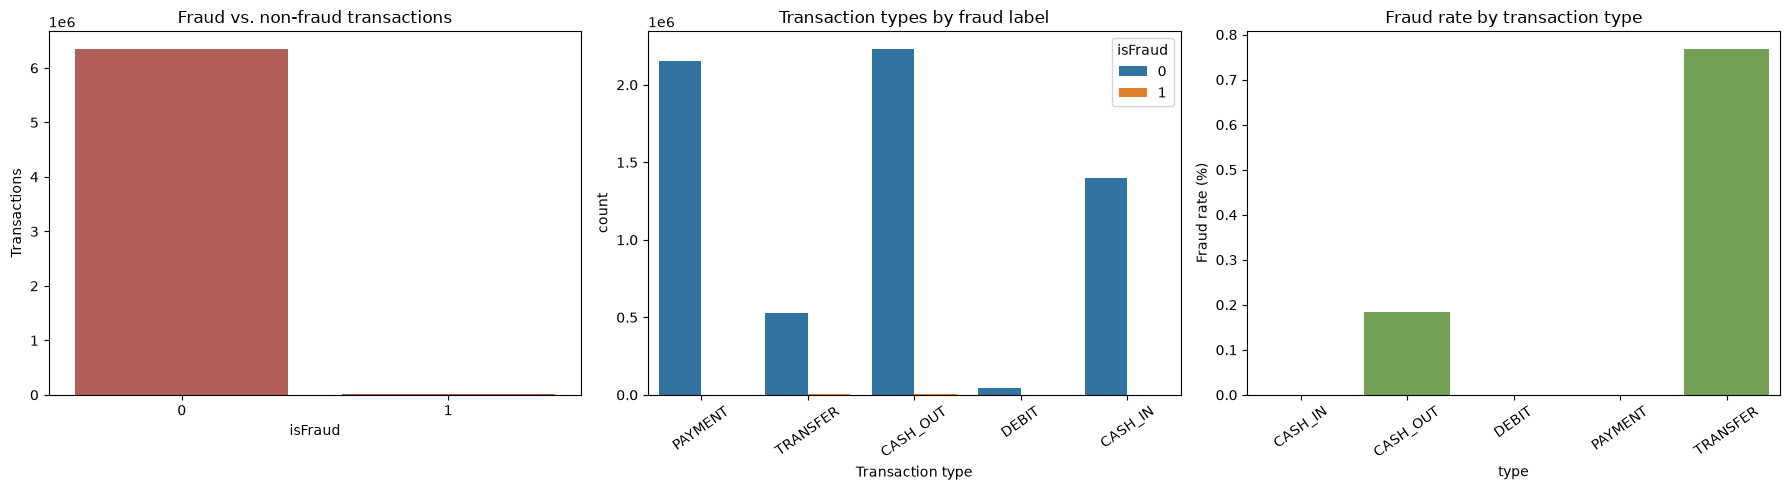

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x="isFraud", ax=axes[0], color="#C0504D")
axes[0].set_title("Fraud vs. non-fraud transactions")
axes[0].set_xlabel("isFraud")
axes[0].set_ylabel("Transactions")
sns.countplot(data=df, x="type", hue="isFraud", ax=axes[1])
axes[1].set_title("Transaction types by fraud label")
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_xlabel("Transaction type")
sns.barplot(data=type_summary.reset_index(), x="type", y="fraud_rate_%", ax=axes[2], color="#70AD47")
axes[2].set_title("Fraud rate by transaction type")
axes[2].tick_params(axis="x", rotation=35)
axes[2].set_ylabel("Fraud rate (%)")
plt.tight_layout()
plt.show()

In [14]:
# 3. Amount and balance distributions
plot_sample = df.sample(n=min(100000, len(df)), random_state=42)
numeric_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08


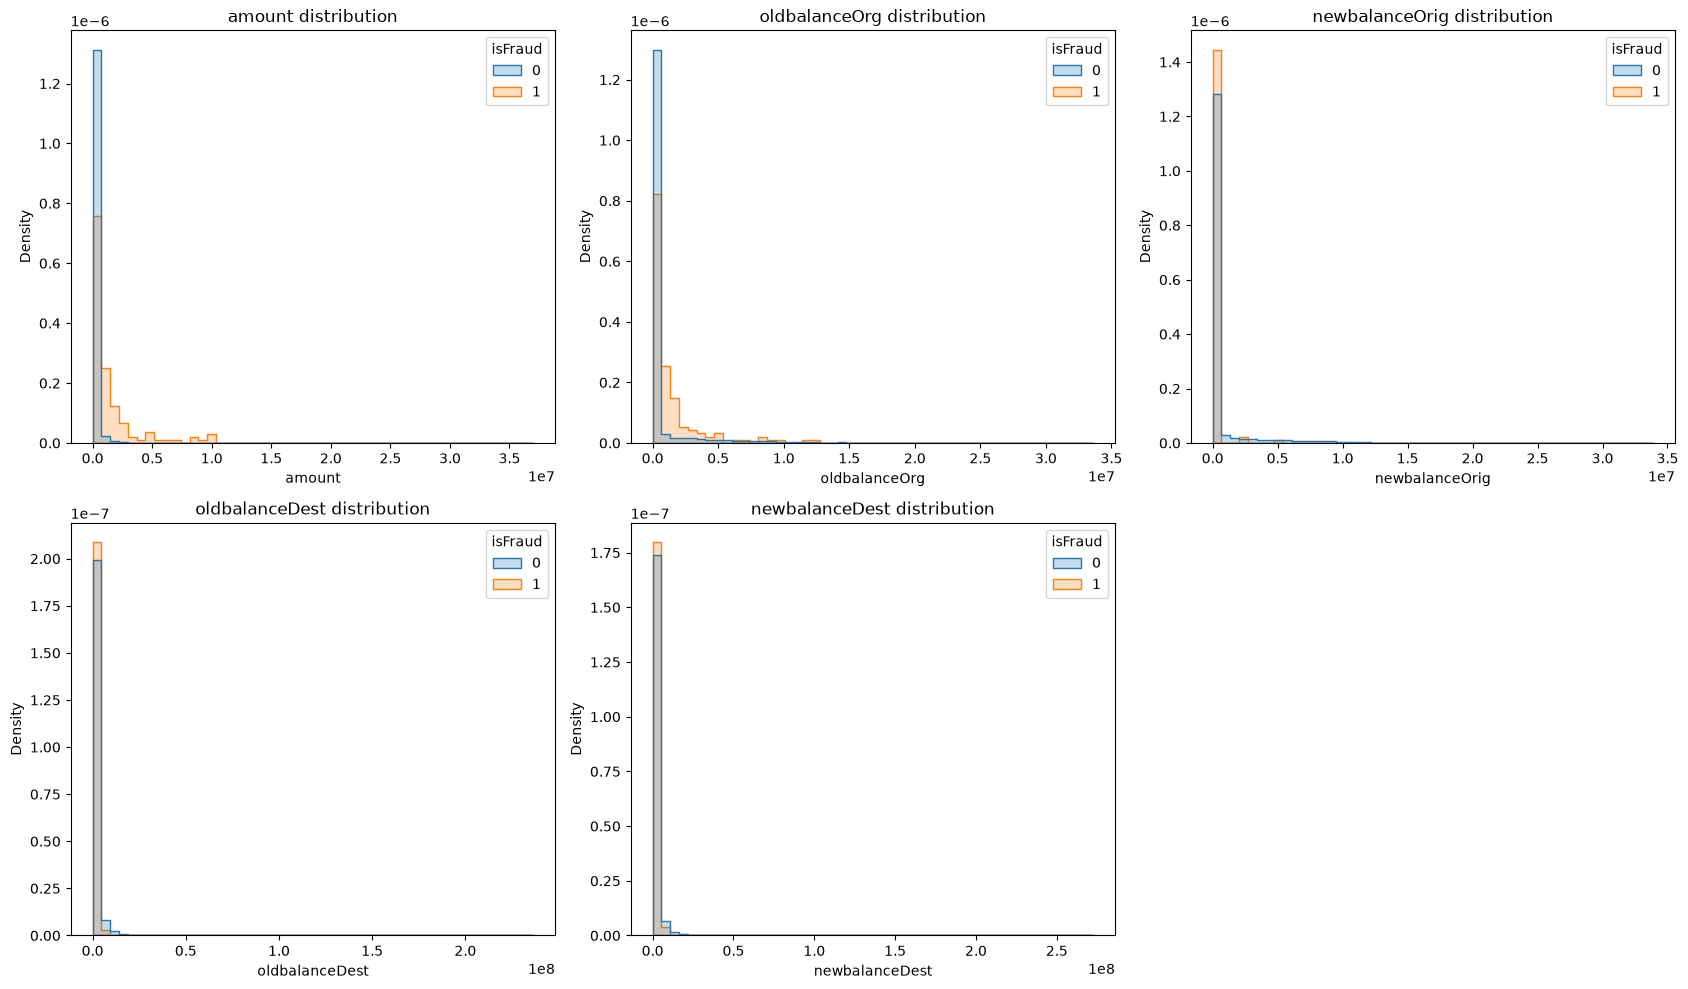

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for axis, column in zip(axes.flat, numeric_cols):
    sns.histplot(data=plot_sample, x=column, hue="isFraud", bins=50, element="step", stat="density", common_norm=False, ax=axis)
    axis.set_title(f"{column} distribution")
    axis.set_xlabel(column)
axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()

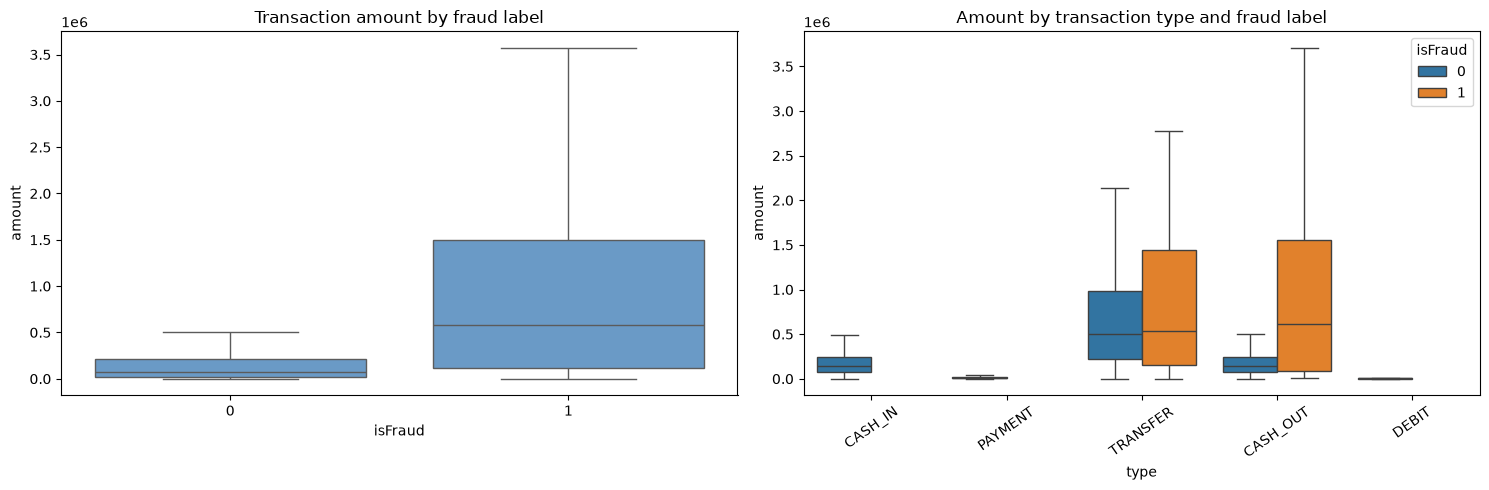

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=plot_sample, x="isFraud", y="amount", ax=axes[0], showfliers=False, color="#5B9BD5")
axes[0].set_title("Transaction amount by fraud label")
axes[0].set_xlabel("isFraud")
sns.boxplot(data=plot_sample, x="type", y="amount", hue="isFraud", ax=axes[1], showfliers=False)
axes[1].set_title("Amount by transaction type and fraud label")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

In [17]:
# 4. Balance consistency and suspicious transaction indicators
eda = df.copy()
eda["origin_balance_error"] = (eda["oldbalanceOrg"] - eda["amount"] - eda["newbalanceOrig"]).abs()
eda["destination_balance_error"] = (eda["oldbalanceDest"] + eda["amount"] - eda["newbalanceDest"]).abs()
eda["origin_zero_after_transaction"] = (eda["newbalanceOrig"] == 0).astype(int)
eda["destination_zero_before_transaction"] = (eda["oldbalanceDest"] == 0).astype(int)
eda["large_amount"] = (eda["amount"] >= eda["amount"].quantile(0.99)).astype(int)
balance_plot_sample = eda.sample(n=min(100000, len(eda)), random_state=42)

In [18]:
consistency_summary = pd.DataFrame({
    "origin_balance_error_gt_1": [int((eda["origin_balance_error"] > 1).sum())],
    "destination_balance_error_gt_1": [int((eda["destination_balance_error"] > 1).sum())],
    "origin_zero_after_transaction": [int(eda["origin_zero_after_transaction"].sum())],
    "destination_zero_before_transaction": [int(eda["destination_zero_before_transaction"].sum())],
    "large_amount_transactions": [int(eda["large_amount"].sum())],
})
display(consistency_summary)

,origin_balance_error_gt_1,destination_balance_error_gt_1,origin_zero_after_transaction,destination_zero_before_transaction,large_amount_transactions
0,5000784,3823834,3609566,2704388,63627


In [19]:
indicator_cols = ["origin_zero_after_transaction", "destination_zero_before_transaction", "large_amount"]
indicator_rates = eda.groupby("isFraud")[indicator_cols].mean().T * 100
indicator_rates.columns = ["not_fraud_rate_%", "fraud_rate_%"]
display(indicator_rates.round(2))

,not_fraud_rate_%,fraud_rate_%
origin_zero_after_transaction,56.68,98.05
destination_zero_before_transaction,42.48,65.15
large_amount,0.97,23.97


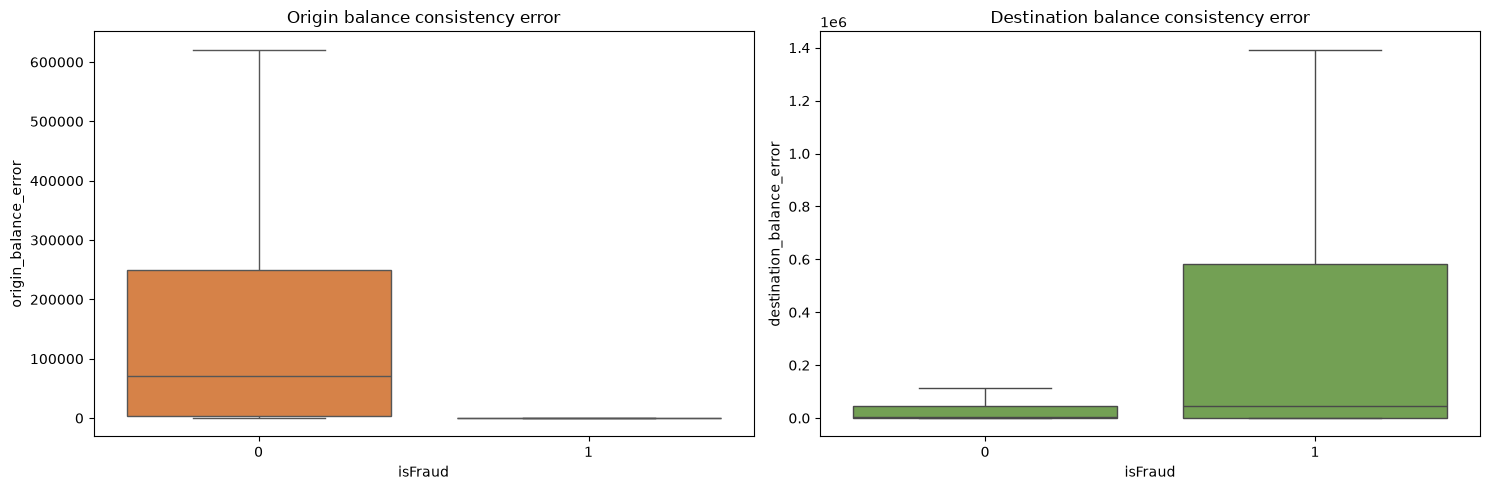

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=balance_plot_sample, x="isFraud", y="origin_balance_error", showfliers=False, ax=axes[0], color="#ED7D31")
axes[0].set_title("Origin balance consistency error")
axes[0].set_xlabel("isFraud")
sns.boxplot(data=balance_plot_sample, x="isFraud", y="destination_balance_error", showfliers=False, ax=axes[1], color="#70AD47")
axes[1].set_title("Destination balance consistency error")
axes[1].set_xlabel("isFraud")
plt.tight_layout()
plt.show()

In [21]:
# 5. Time-based fraud patterns
eda["day"] = eda["step"] // 24
eda["hour"] = eda["step"] % 24
time_summary = eda.groupby("hour").agg(
    transactions=("isFraud", "size"),
    fraud_count=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
 )
time_summary["fraud_rate_%"] = (time_summary["fraud_rate"] * 100).round(4)
display(time_summary.drop(columns="fraud_rate"))

,transactions,fraud_count,fraud_rate_%
hour,,,
0,71587,300,0.4191
1,27111,358,1.3205
2,9018,372,4.1251
3,2007,326,16.2431
4,1241,274,22.0790
5,1641,366,22.3035
6,3420,358,10.4678
7,8988,328,3.6493
8,26915,368,1.3673


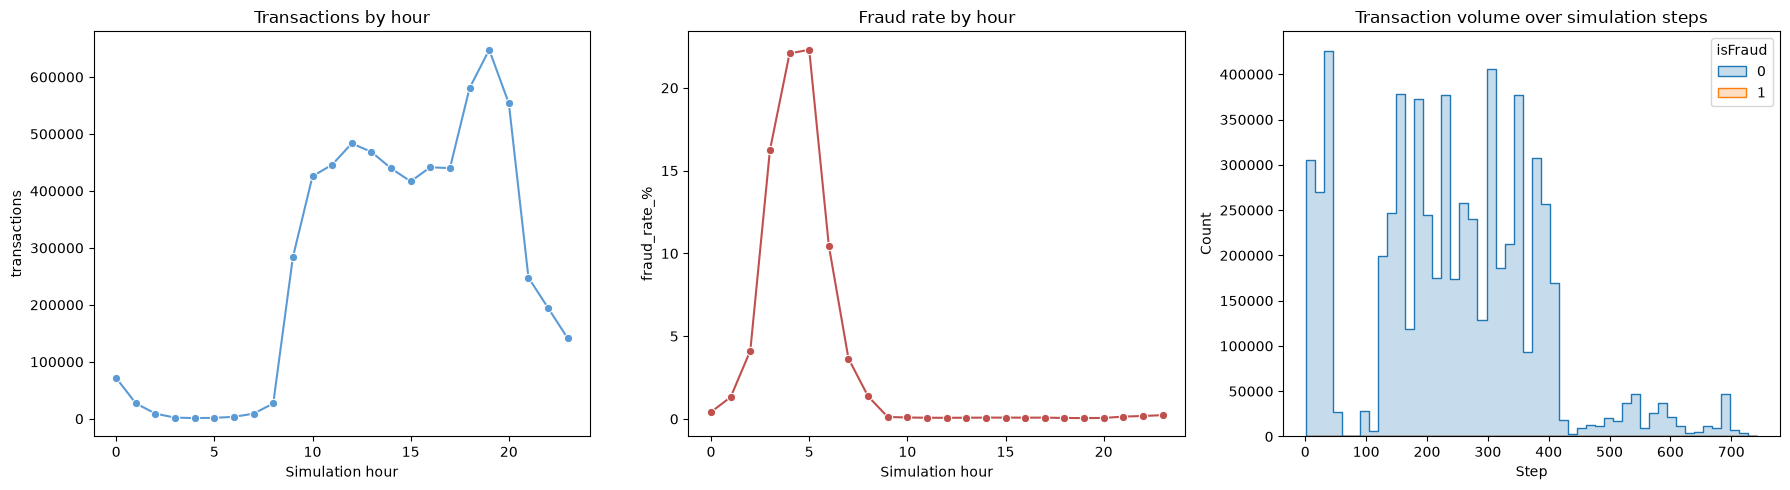

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=time_summary, x=time_summary.index, y="transactions", marker="o", ax=axes[0], color="#5B9BD5")
axes[0].set_title("Transactions by hour")
axes[0].set_xlabel("Simulation hour")
sns.lineplot(data=time_summary, x=time_summary.index, y="fraud_rate_%", marker="o", ax=axes[1], color="#C0504D")
axes[1].set_title("Fraud rate by hour")
axes[1].set_xlabel("Simulation hour")
sns.histplot(data=eda, x="step", hue="isFraud", bins=50, element="step", stat="count", common_norm=False, ax=axes[2])
axes[2].set_title("Transaction volume over simulation steps")
axes[2].set_xlabel("Step")
plt.tight_layout()
plt.show()

In [23]:
# 6. Rule-based flag performance and fraud association
flag_confusion = pd.crosstab(
    df["isFraud"],
    df["isFlaggedFraud"],
    rownames=["actual_fraud"],
    colnames=["flagged_fraud"],
    dropna=False,
 )
display(flag_confusion)

flagged_fraud,0,1
actual_fraud,,
0,6354407,0
1,8197,16


In [24]:
flag_metrics = {
    "actual_fraud_count": int(df["isFraud"].sum()),
    "flagged_fraud_count": int(df["isFlaggedFraud"].sum()),
    "true_positive_count": int(((df["isFraud"] == 1) & (df["isFlaggedFraud"] == 1)).sum()),
    "false_positive_count": int(((df["isFraud"] == 0) & (df["isFlaggedFraud"] == 1)).sum()),
    "fraud_recall_of_rule_%": round(((df["isFraud"] & df["isFlaggedFraud"]).sum() / df["isFraud"].sum()) * 100, 4),
}
display(pd.Series(flag_metrics).to_frame("value"))

,value
actual_fraud_count,8213.0000
flagged_fraud_count,16.0000
true_positive_count,16.0000
false_positive_count,0.0000
fraud_recall_of_rule_%,0.1948


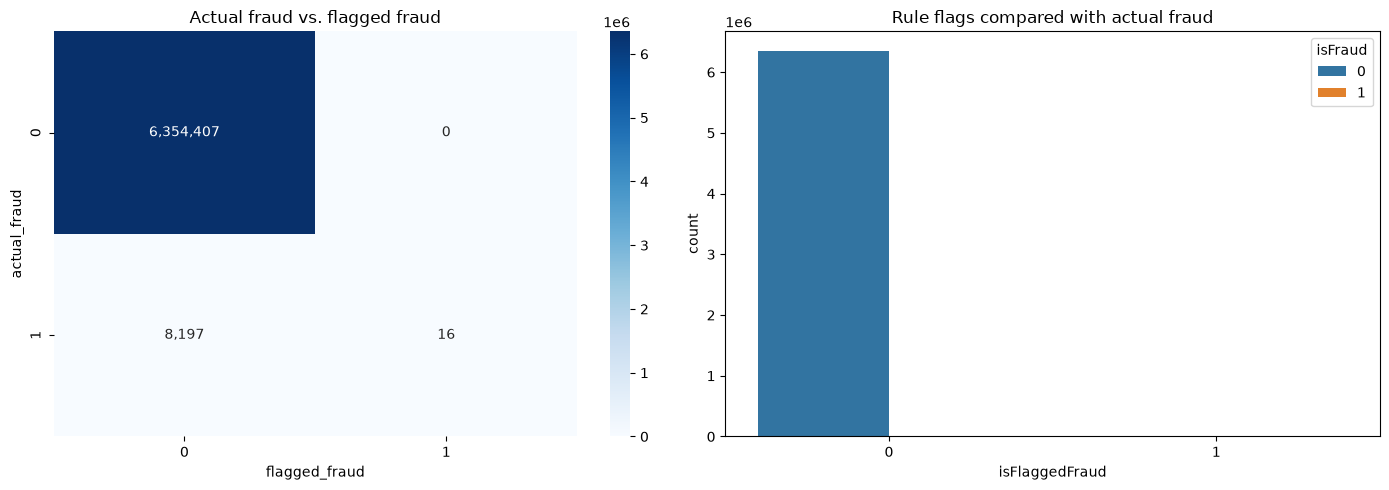

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(flag_confusion, annot=True, fmt=",", cmap="Blues", ax=axes[0])
axes[0].set_title("Actual fraud vs. flagged fraud")
sns.countplot(data=df, x="isFlaggedFraud", hue="isFraud", ax=axes[1])
axes[1].set_title("Rule flags compared with actual fraud")
axes[1].set_xlabel("isFlaggedFraud")
plt.tight_layout()
plt.show()

In [26]:
# 7. Account activity concentration and correlations
origin_counts = df["nameOrig"].value_counts()
destination_counts = df["nameDest"].value_counts()
activity_summary = pd.DataFrame({
    "origin_transactions": origin_counts.describe(),
    "destination_transactions": destination_counts.describe(),
})
display(activity_summary)

,origin_transactions,destination_transactions
count,6.353307e+06,2.722362e+06
mean,1.001466e+00,2.337169e+00
std,3.832002e-02,4.549264e+00
min,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,1.000000e+00,1.000000e+00
max,3.000000e+00,1.130000e+02


In [27]:
print("Top origin accounts by transaction count:")
display(origin_counts.head(10).to_frame("transaction_count"))

Top origin accounts by transaction count:


,transaction_count
nameOrig,
C2098525306,3
C400299098,3
C1999539787,3
C1065307291,3
C545315117,3
C1976208114,3
C1784010646,3
C1530544995,3
C1902386530,3


In [28]:
print("Top destination accounts by transaction count:")
display(destination_counts.head(10).to_frame("transaction_count"))

Top destination accounts by transaction count:


,transaction_count
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101
C1590550415,101
C451111351,99
C1789550256,99
C1360767589,98


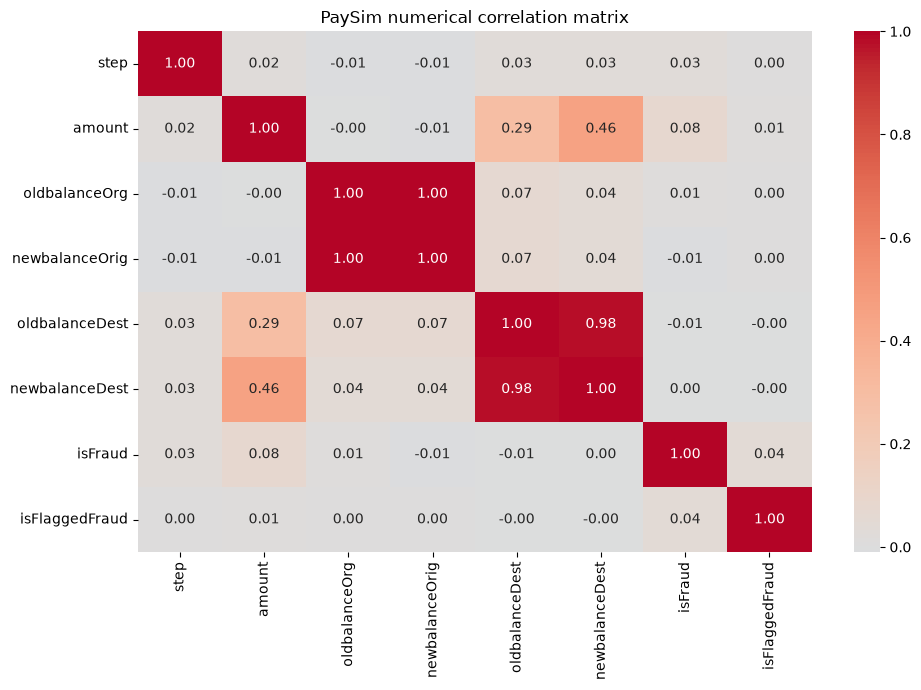

In [29]:
corr_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud", "isFlaggedFraud"]
plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("PaySim numerical correlation matrix")
plt.tight_layout()
plt.show()

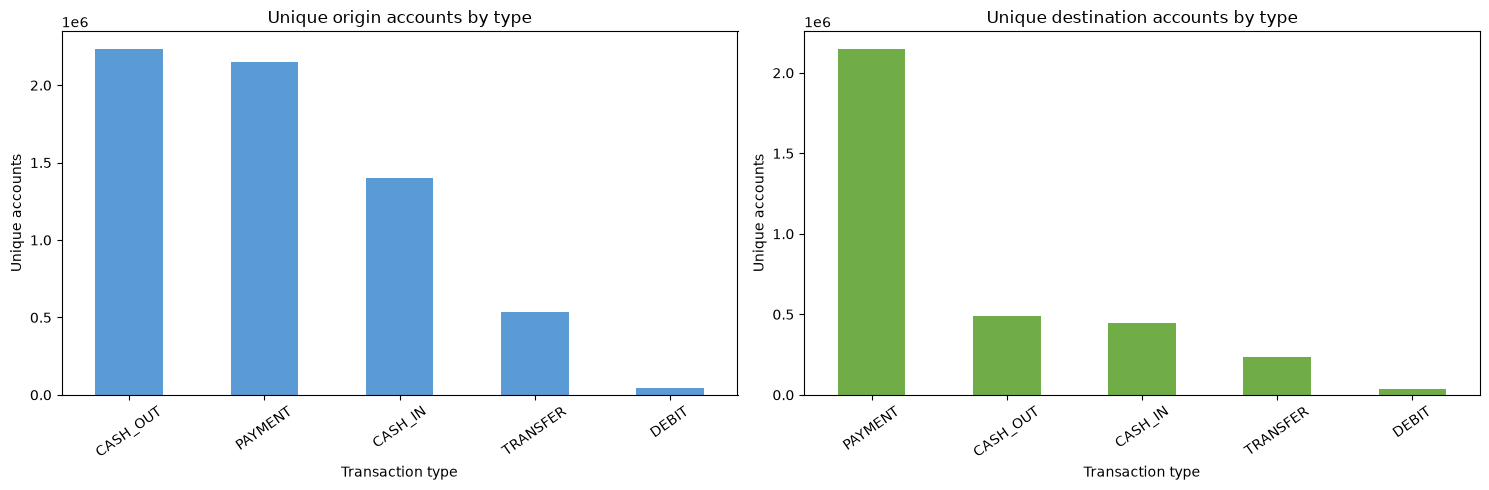

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
origin_fraud = df.groupby("type")["nameOrig"].nunique().sort_values(ascending=False)
destination_fraud = df.groupby("type")["nameDest"].nunique().sort_values(ascending=False)
origin_fraud.plot(kind="bar", ax=axes[0], color="#5B9BD5", title="Unique origin accounts by type")
destination_fraud.plot(kind="bar", ax=axes[1], color="#70AD47", title="Unique destination accounts by type")
for axis in axes:
    axis.tick_params(axis="x", rotation=35)
    axis.set_xlabel("Transaction type")
    axis.set_ylabel("Unique accounts")
plt.tight_layout()
plt.show()

## EDA Findings and Modelling Guidance

- `isFraud` is the supervised learning target: `0` means legitimate and `1` means fraudulent.
- `isFlaggedFraud` is an existing rule-based alert and must not be treated as the same thing as confirmed fraud; use it for baseline comparison or exclude it to avoid leakage.
- Fraud is highly imbalanced, so use precision, recall, F1, PR-AUC, ROC-AUC, and a confusion matrix rather than accuracy alone.
- `nameOrig` and `nameDest` are identifiers. Drop them from a basic model or transform them into historical account-level behavior features using a time-aware procedure.
- Preserve `step` for time-based validation and monitoring. Do not randomly mix future transactions into training if production realism matters.
- Balance inconsistency features and zero-balance indicators can be useful fraud signals, but they should be evaluated only on the information available at decision time.
- Use the transaction type, amount, balance changes, and time patterns for feature engineering and SHAP explanations.

## Fraud Model: XGBoost with Time-Based Validation

XGBoost is used for this tabular, highly imbalanced fraud problem. The split is chronological: earlier transactions train the model and later transactions test it. `isFlaggedFraud` is excluded because it is a pre-existing rule alert that would leak rule information into the learned model.

In [31]:
model_df = df.copy()
model_df["hour"] = model_df["step"] % 24
model_df["day"] = model_df["step"] // 24
model_df["origin_balance_error"] = (model_df["oldbalanceOrg"] - model_df["amount"] - model_df["newbalanceOrig"]).abs()
model_df["destination_balance_error"] = (model_df["oldbalanceDest"] + model_df["amount"] - model_df["newbalanceDest"]).abs()
model_df["origin_zero_after"] = (model_df["newbalanceOrig"] == 0).astype(int)
model_df["destination_zero_before"] = (model_df["oldbalanceDest"] == 0).astype(int)
model_df["amount_to_origin_balance"] = np.where(
    model_df["oldbalanceOrg"] > 0,
    model_df["amount"] / model_df["oldbalanceOrg"],
    0,
)

In [32]:
model_df = pd.get_dummies(model_df, columns=["type"], dtype=int)

feature_cols = [
    "step", "hour", "day", "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest", "origin_balance_error",
    "destination_balance_error", "origin_zero_after",
    "destination_zero_before", "amount_to_origin_balance",
    "type_CASH_IN", "type_CASH_OUT", "type_DEBIT", "type_PAYMENT", "type_TRANSFER",
 ]
feature_cols = [column for column in feature_cols if column in model_df.columns]
X = model_df[feature_cols].astype("float32")
y = model_df["isFraud"].astype(int)

In [33]:
split_point = model_df["step"].quantile(0.80)
train_mask = model_df["step"] <= split_point
test_mask = ~train_mask
X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [34]:
fraud_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric=["aucpr", "logloss"],
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
 )

In [36]:
fraud_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100,
)

[0]	validation_0-aucpr:0.99251	validation_0-logloss:0.64496	validation_1-aucpr:0.99558	validation_1-logloss:0.64467
[100]	validation_0-aucpr:0.99943	validation_0-logloss:0.00535	validation_1-aucpr:0.99996	validation_1-logloss:0.00366
[200]	validation_0-aucpr:0.99989	validation_0-logloss:0.00057	validation_1-aucpr:0.99996	validation_1-logloss:0.00008
[300]	validation_0-aucpr:1.00000	validation_0-logloss:0.00013	validation_1-aucpr:0.99997	validation_1-logloss:0.00002
[400]	validation_0-aucpr:1.00000	validation_0-logloss:0.00004	validation_1-aucpr:0.99997	validation_1-logloss:0.00001
[499]	validation_0-aucpr:1.00000	validation_0-logloss:0.00002	validation_1-aucpr:0.99998	validation_1-logloss:0.00001


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])","['aucpr', 'logloss']"
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [47]:
# Important: create probabilities before threshold logic
test_probabilities = fraud_model.predict_proba(X_test)[:, 1]

In [50]:
# Threshold selection under an operational review-rate constraint
precision, recall, thresholds = precision_recall_curve(y_test, test_probabilities)
threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
})

In [52]:
threshold_table["review_rate"] = [(test_probabilities >= value).mean() for value in thresholds]
threshold_table["f1"] = (2 * threshold_table["precision"] * threshold_table["recall"] / (threshold_table["precision"] + threshold_table["recall"]).replace(0, np.nan)).fillna(0)
feasible_thresholds = threshold_table[threshold_table["review_rate"] <= 0.01].copy()
if feasible_thresholds.empty:
    best_threshold_row = threshold_table.loc[threshold_table["f1"].idxmax()]
else:
    best_threshold_row = feasible_thresholds.loc[feasible_thresholds["f1"].idxmax()]
selected_threshold = float(best_threshold_row["threshold"])
selected_predictions = (test_probabilities >= selected_threshold).astype(int)

In [54]:
selected_threshold

0.9987810254096985

In [59]:
print(f"Selected threshold: {selected_threshold:.6f}")
print(f"Expected review rate: {(selected_predictions.mean()):.4%}")
print(f"Precision: {precision_score(y_test, selected_predictions, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, selected_predictions, zero_division=0):.4f}")
print(f"F1: {f1_score(y_test, selected_predictions, zero_division=0):.4f}")
display(pd.DataFrame(confusion_matrix(y_test, selected_predictions), index=["actual_0", "actual_1"], columns=["predicted_0", "predicted_1"]))

Selected threshold: 0.998781
Expected review rate: 0.3402%
Precision: 1.0000
Recall: 0.9995
F1: 0.9998


,predicted_0,predicted_1
actual_0,1244486,0
actual_1,2,4248


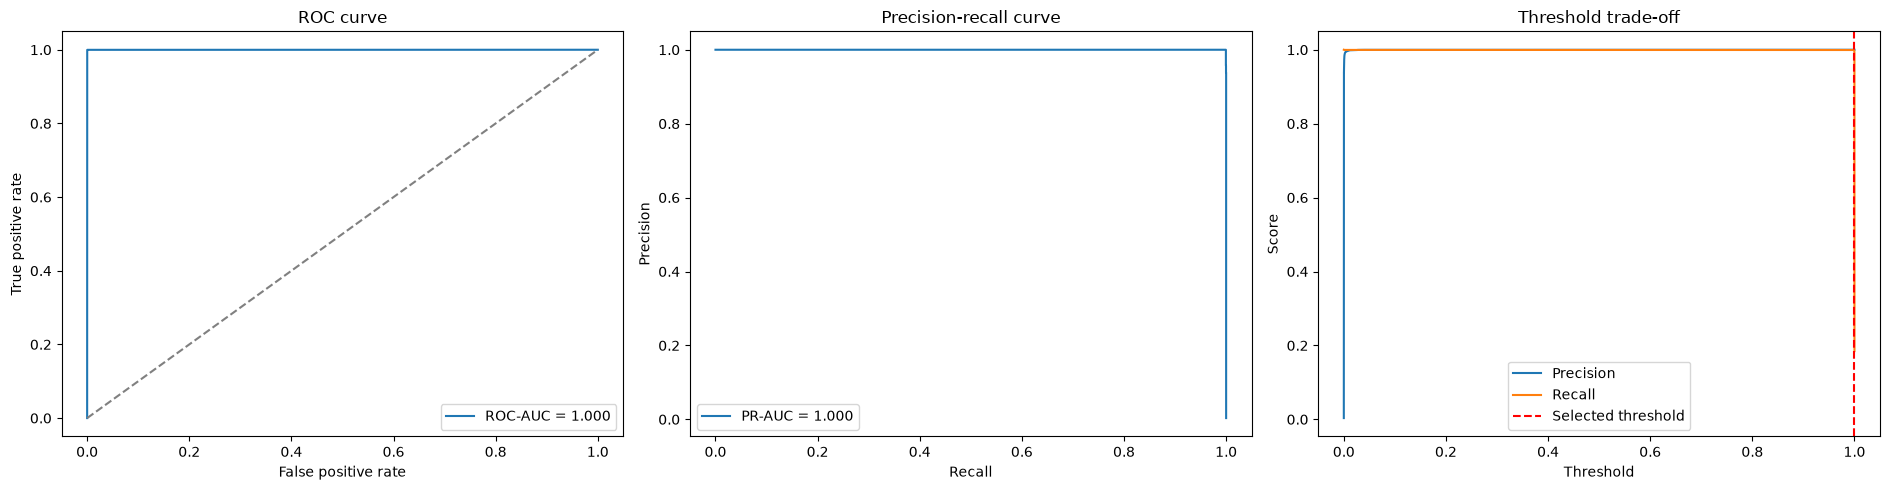

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fpr, tpr, _ = roc_curve(y_test, test_probabilities)
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, test_probabilities):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()
axes[1].plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test, test_probabilities):.3f}")
axes[1].set_title("Precision-recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[2].plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
axes[2].plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
axes[2].axvline(selected_threshold, color="red", linestyle="--", label="Selected threshold")
axes[2].set_title("Threshold trade-off")
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("Score")
axes[2].legend()
plt.tight_layout()
plt.show()

In [65]:
# test_results = model_df.loc[test_mask, ["type", "isFraud"]].copy()

In [66]:
# Validation by transaction type and model artifact export
test_results = df.loc[test_mask, ["type", "isFraud"]].copy()
test_results["probability"] = test_probabilities
test_results["prediction"] = selected_predictions

type_validation = (
    test_results.groupby("type", dropna=False)
    .apply(
        lambda group: pd.Series({
            "transactions": len(group),
            "fraud_count": int(group["isFraud"].sum()),
            "fraud_rate_%": group["isFraud"].mean() * 100,
            "pr_auc": average_precision_score(group["isFraud"], group["probability"])
                if group["isFraud"].nunique() > 1 else np.nan,
            "recall": recall_score(group["isFraud"], group["prediction"], zero_division=0),
        })
    )
    .round(4)
)

display(type_validation)

,transactions,fraud_count,fraud_rate_%,pr_auc,recall
type,,,,,
CASH_IN,276810.0,0.0,0.0000,NaN,0.0000
CASH_OUT,423501.0,2125.0,0.5018,1.0,1.0000
DEBIT,8899.0,0.0,0.0000,NaN,0.0000
PAYMENT,431087.0,0.0,0.0000,NaN,0.0000
TRANSFER,108439.0,2125.0,1.9596,1.0,0.9991


In [72]:
# df.shape

In [71]:
# model_df.

In [77]:
model_df.columns

Index(['step', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'hour', 'day', 'origin_balance_error',
       'destination_balance_error', 'origin_zero_after',
       'destination_zero_before', 'amount_to_origin_balance', 'type_CASH_IN',
       'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='str')

In [80]:
# Validation by transaction type and model artifact export
test_results = df.loc[test_mask, ["type", "isFraud"]].copy()
test_results["probability"] = test_probabilities
test_results["prediction"] = selected_predictions
type_validation = test_results.groupby("type").apply(
    lambda group: pd.Series({
        "transactions": len(group),
        "fraud_count": int(group["isFraud"].sum()),
        "fraud_rate_%": group["isFraud"].mean() * 100,
        "pr_auc": average_precision_score(group["isFraud"], group["probability"]) if group["isFraud"].nunique() > 1 else np.nan,
        "recall": recall_score(group["isFraud"], group["prediction"], zero_division=0),
    }),
    include_groups=False,
 ).round(4)
display(type_validation)

,transactions,fraud_count,fraud_rate_%,pr_auc,recall
type,,,,,
CASH_IN,276810.0,0.0,0.0000,NaN,0.0000
CASH_OUT,423501.0,2125.0,0.5018,1.0,1.0000
DEBIT,8899.0,0.0,0.0000,NaN,0.0000
PAYMENT,431087.0,0.0,0.0000,NaN,0.0000
TRANSFER,108439.0,2125.0,1.9596,1.0,0.9991


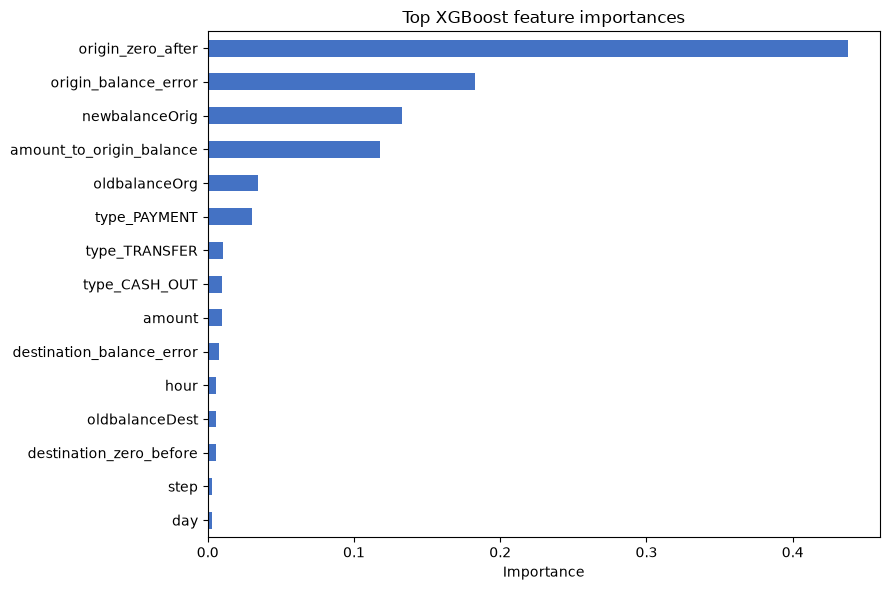

In [62]:
importance = pd.Series(fraud_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 6))
importance.sort_values().plot(kind="barh", color="#4472C4")
plt.title("Top XGBoost feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [63]:
artifact = {
    "model": fraud_model,
    "feature_columns": feature_cols,
    "threshold": selected_threshold,
    "target": "isFraud: 0 = legitimate, 1 = fraud",
    "validation": {
        "split": "chronological 80/20 by step",
        "roc_auc": float(roc_auc_score(y_test, test_probabilities)),
        "pr_auc": float(average_precision_score(y_test, test_probabilities)),
    },
}

In [88]:
print(artifact.items())

dict_items([('model', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=['aucpr', 'logloss'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)), ('feature_columns', ['step', 'hour', 'day', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'origin_balance_error', 'destination_balance_error', 'origin_zero_after

In [81]:
model_path = Path(r"C:/Users/USER/OneDrive/Desktop/AI-Financial-Risk-Intelligence/models/Fraud_models\paysim_fraud_model.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)
with open(model_path, "wb") as file:
    pickle.dump(artifact, file)
print(f"Saved model artifact: {model_path}")

Saved model artifact: C:\Users\USER\OneDrive\Desktop\AI-Financial-Risk-Intelligence\models\Fraud_models\paysim_fraud_model.pkl
